# Twitter Analysis Dataset

In [40]:
# Libraries
from wordcloud import WordCloud
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data = pd.read_csv(r'E:\tvb_25\datasets\Twitter Analysis.csv')
data.head()

,Unnamed: 0,majority_target,statement,BinaryNumTarget,tweet,followers_count,friends_count,favourites_count,statuses_count,listed_count,...,determiners,conjunctions,dots,exclamation,questions,ampersand,capitals,digits,long_word_freq,short_word_freq
0,0,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders - 6 Month Update\n\nInfl...,4262.0,3619.0,34945.0,16423.0,44.0,...,0,0,5,0,1,0,33,3,5,19
1,1,True,End of eviction moratorium means millions of A...,1.0,@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,1393.0,1621.0,31436.0,37184.0,64.0,...,0,2,1,0,0,0,14,0,2,34
2,2,True,End of eviction moratorium means millions of A...,1.0,THE SUPREME COURT is siding with super rich pr...,9.0,84.0,219.0,1184.0,0.0,...,0,1,0,0,0,0,3,0,4,10
3,3,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders\n\nBroken campaign promi...,4262.0,3619.0,34945.0,16423.0,44.0,...,0,1,3,0,0,1,6,8,1,30
4,4,True,End of eviction moratorium means millions of A...,1.0,@OhComfy I agree. The confluence of events rig...,70.0,166.0,15282.0,2194.0,0.0,...,0,1,3,0,1,0,11,3,2,19


In [11]:
# Turn it into a dataframe so it's easier to work with

df = pd.DataFrame(data)
df.head()

,Unnamed: 0,majority_target,statement,BinaryNumTarget,tweet,followers_count,friends_count,favourites_count,statuses_count,listed_count,...,determiners,conjunctions,dots,exclamation,questions,ampersand,capitals,digits,long_word_freq,short_word_freq
0,0,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders - 6 Month Update\n\nInfl...,4262.0,3619.0,34945.0,16423.0,44.0,...,0,0,5,0,1,0,33,3,5,19
1,1,True,End of eviction moratorium means millions of A...,1.0,@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,1393.0,1621.0,31436.0,37184.0,64.0,...,0,2,1,0,0,0,14,0,2,34
2,2,True,End of eviction moratorium means millions of A...,1.0,THE SUPREME COURT is siding with super rich pr...,9.0,84.0,219.0,1184.0,0.0,...,0,1,0,0,0,0,3,0,4,10
3,3,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders\n\nBroken campaign promi...,4262.0,3619.0,34945.0,16423.0,44.0,...,0,1,3,0,0,1,6,8,1,30
4,4,True,End of eviction moratorium means millions of A...,1.0,@OhComfy I agree. The confluence of events rig...,70.0,166.0,15282.0,2194.0,0.0,...,0,1,3,0,1,0,11,3,2,19


## Basic data exploration

In [12]:
df.shape
# 134,198 rows
# 64 columns

(134198, 64)

In [13]:
# Checking for missing values
df.isnull().sum()

Unnamed: 0         0
majority_target    0
statement          0
BinaryNumTarget    0
tweet              0
                  ..
ampersand          0
capitals           0
digits             0
long_word_freq     0
short_word_freq    0
Length: 64, dtype: int64

In [14]:
# Descriptive statistics
df.describe()

,Unnamed: 0,BinaryNumTarget,followers_count,friends_count,favourites_count,statuses_count,listed_count,following,BotScore,BotScoreBinary,...,determiners,conjunctions,dots,exclamation,questions,ampersand,capitals,digits,long_word_freq,short_word_freq
count,134198.00000,134198.000000,1.341980e+05,134198.000000,1.341980e+05,1.341980e+05,134198.000000,134198.0,134198.000000,134198.000000,...,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000
mean,67098.50000,0.513644,1.129308e+04,1893.454455,3.298123e+04,3.419576e+04,73.300198,0.0,0.059106,0.032355,...,0.135583,1.003495,2.366116,0.259408,0.307151,0.121537,12.831905,3.559494,2.249557,21.438658
std,38739.77005,0.499816,4.374971e+05,6997.695671,6.878021e+04,7.510120e+04,1083.274277,0.0,0.167819,0.176942,...,0.379235,1.086844,2.140459,0.903957,0.774367,0.453865,15.557524,6.674458,2.912136,9.625147
min,0.00000,0.000000,0.000000e+00,0.000000,0.000000e+00,1.000000e+00,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33549.25000,0.000000,7.000000e+01,168.000000,1.356000e+03,3.046000e+03,0.000000,0.0,0.030000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,6.000000,0.000000,1.000000,14.000000
50%,67098.50000,1.000000,3.540000e+02,567.000000,8.377000e+03,1.101900e+04,2.000000,0.0,0.030000,0.000000,...,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,10.000000,2.000000,2.000000,21.000000
75%,100647.75000,1.000000,1.573000e+03,1726.000000,3.352650e+04,3.357375e+04,11.000000,0.0,0.030000,0.000000,...,0.000000,2.000000,3.000000,0.000000,0.000000,0.000000,15.000000,4.000000,3.000000,28.000000
max,134197.00000,1.000000,1.306019e+08,586901.000000,1.765080e+06,2.958918e+06,222193.000000,0.0,1.000000,1.000000,...,5.000000,13.000000,50.000000,66.000000,43.000000,13.000000,250.000000,138.000000,47.000000,164.000000


In [15]:
df.info

<bound method DataFrame.info of         Unnamed: 0  majority_target  \
0                0             True   
1                1             True   
2                2             True   
3                3             True   
4                4             True   
...            ...              ...   
134193      134193            False   
134194      134194            False   
134195      134195            False   
134196      134196            False   
134197      134197            False   

                                                statement  BinaryNumTarget  \
0       End of eviction moratorium means millions of A...              1.0   
1       End of eviction moratorium means millions of A...              1.0   
2       End of eviction moratorium means millions of A...              1.0   
3       End of eviction moratorium means millions of A...              1.0   
4       End of eviction moratorium means millions of A...              1.0   
...                            

### OLS, Variable significance

AVAILABLE COLUMNS IN DATAFRAME
['Unnamed: 0', 'majority_target', 'statement', 'BinaryNumTarget', 'tweet', 'followers_count', 'friends_count', 'favourites_count', 'statuses_count', 'listed_count', 'following', 'embeddings', 'BotScore', 'BotScoreBinary', 'cred', 'normalize_influence', 'mentions', 'quotes', 'replies', 'retweets', 'favourites', 'hashtags', 'URLs', 'unique_count', 'total_count', 'ORG_percentage', 'NORP_percentage', 'GPE_percentage', 'PERSON_percentage', 'MONEY_percentage', 'DATE_percentage', 'CARDINAL_percentage', 'PERCENT_percentage', 'ORDINAL_percentage', 'FAC_percentage', 'LAW_percentage', 'PRODUCT_percentage', 'EVENT_percentage', 'TIME_percentage', 'LOC_percentage', 'WORK_OF_ART_percentage', 'QUANTITY_percentage', 'LANGUAGE_percentage', 'Word count', 'Max word length', 'Min word length', 'Average word length', 'present_verbs', 'past_verbs', 'adjectives', 'adverbs', 'adpositions', 'pronouns', 'TOs', 'determiners', 'conjunctions', 'dots', 'exclamation', 'questions', 'ampe

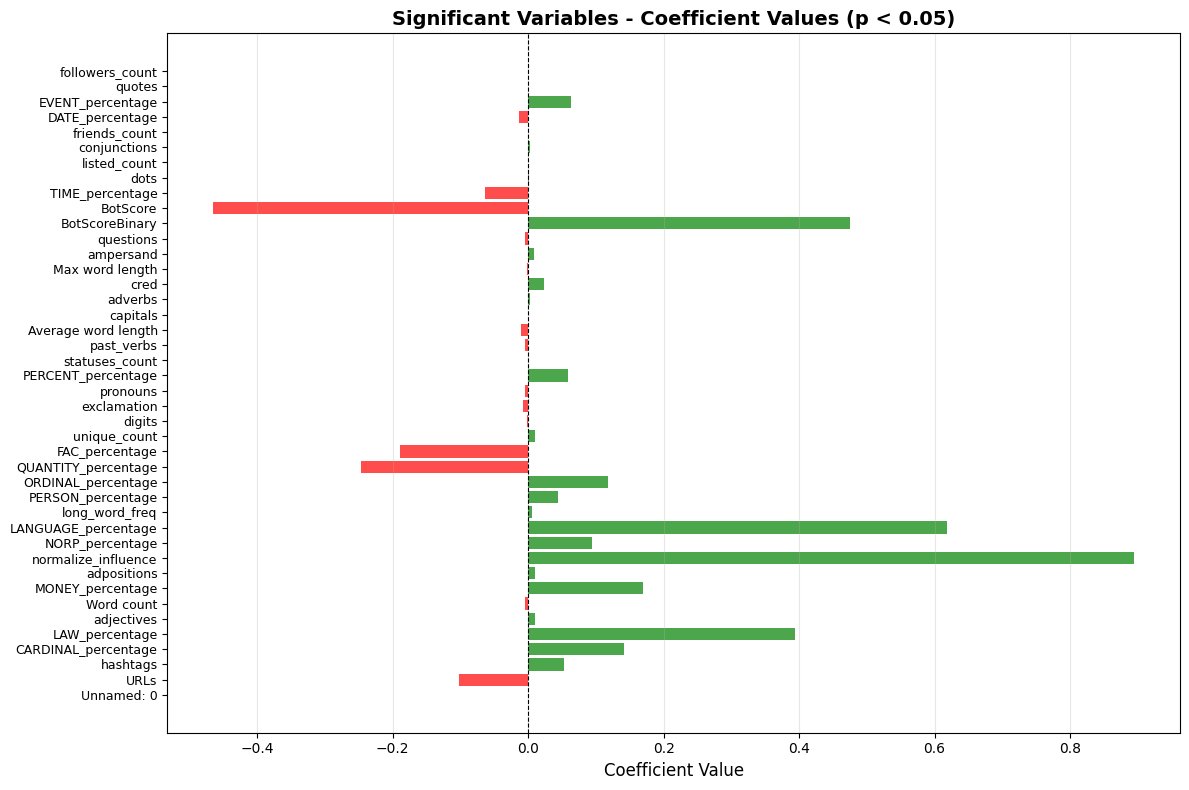

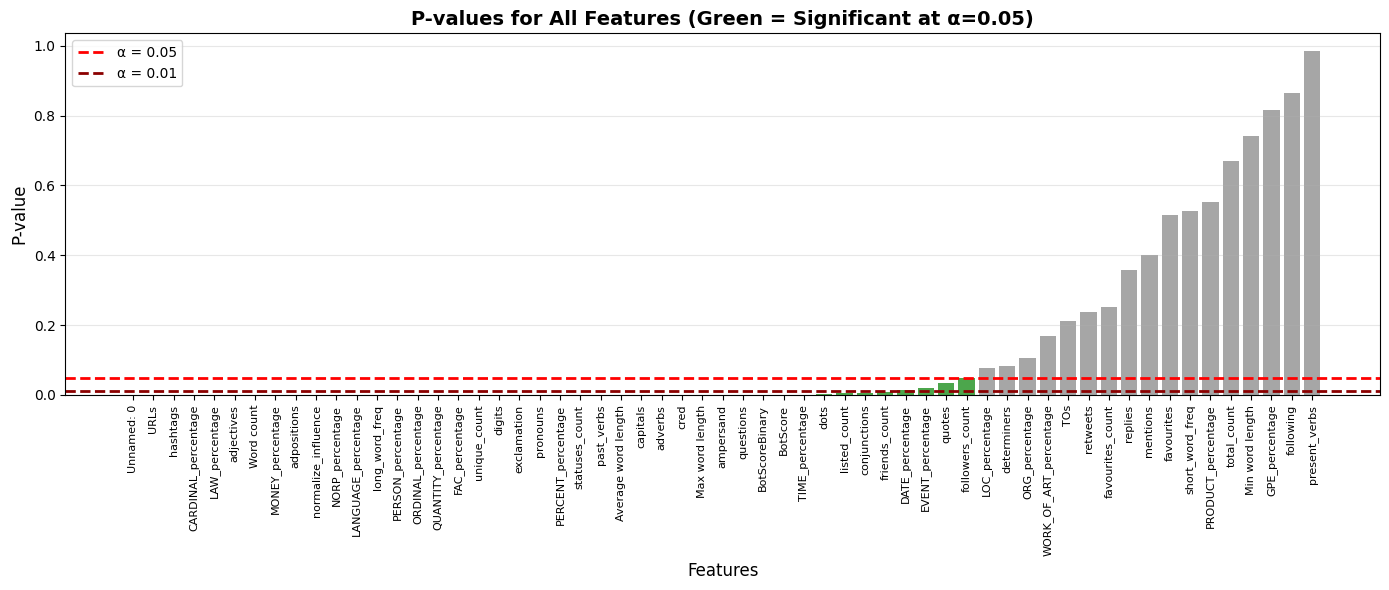

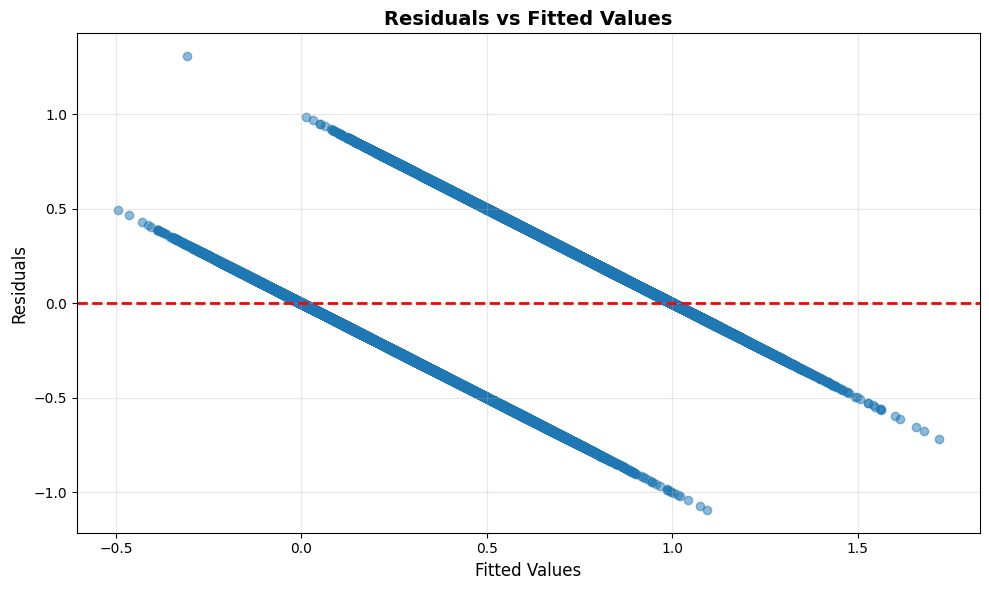

VARIANCE INFLATION FACTOR (VIF) - Top 10 Highest
Checking for multicollinearity (VIF > 10 indicates high multicollinearity)


C:\Users\alfar\ML_methodology\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


                Feature         VIF
7              BotScore  688.612862
8        BotScoreBinary  640.331926
38           Word count   96.583887
41  Average word length   50.126059
58      short_word_freq   49.371169
39      Max word length   29.443998
10  normalize_influence   24.020644
18         unique_count   14.412849
14             retweets   12.457154
19          total_count   11.555190

Features with VIF > 10: 10

                Feature         VIF
7              BotScore  688.612862
8        BotScoreBinary  640.331926
38           Word count   96.583887
41  Average word length   50.126059
58      short_word_freq   49.371169
39      Max word length   29.443998
10  normalize_influence   24.020644
18         unique_count   14.412849
14             retweets   12.457154
19          total_count   11.555190


In [42]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Define your target
target = 'BinaryNumTarget'

# Check what columns are available
print("=" * 80)
print("AVAILABLE COLUMNS IN DATAFRAME")
print("=" * 80)
print(df.columns.tolist())
print(f"\nTotal columns: {len(df.columns)}")
print("\n")

# Exclude non-numeric and target columns
exclude_cols = ['majority_target', 'BinaryNumTarget', 'statement', 'tweet']

# Get all numeric columns except the excluded ones
features = [col for col in df.columns if col not in exclude_cols]

# Filter to only numeric columns
numeric_features = df[features].select_dtypes(include=[np.number]).columns.tolist()

print("=" * 80)
print("FEATURES USED FOR REGRESSION")
print("=" * 80)
print(f"Total features: {len(numeric_features)}")
print("\nFeatures:")
for i, feat in enumerate(numeric_features, 1):
    print(f"{i}. {feat}")
print("\n")

# Handle missing values
df_clean = df[numeric_features + [target]].dropna()

print("=" * 80)
print("DATA SUMMARY")
print("=" * 80)
print(f"Original rows: {len(df)}")
print(f"Rows after removing missing values: {len(df_clean)}")
print(f"Rows dropped: {len(df) - len(df_clean)}")
print("\n")

# Prepare data
X = df_clean[numeric_features]
y = df_clean[target]                # binary 0/1

# Add constant for intercept
X_with_const = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_with_const)
results = model.fit()

# Print comprehensive results
print("=" * 80)
print("OLS REGRESSION RESULTS")
print("=" * 80)
print(results.summary())
print("\n")

# Extract significant variables (p < 0.05)
print("=" * 80)
print("SIGNIFICANT VARIABLES (p < 0.05)")
print("=" * 80)
sig_vars = results.pvalues[results.pvalues < 0.05].sort_values()
print(sig_vars)
print(f"\nTotal significant variables: {len(sig_vars) - 1}")  # -1 for constant
print("\n")

# Extract highly significant variables (p < 0.01)
print("=" * 80)
print("HIGHLY SIGNIFICANT VARIABLES (p < 0.01)")
print("=" * 80)
highly_sig = results.pvalues[results.pvalues < 0.01].sort_values()
print(highly_sig)
print(f"\nTotal highly significant variables: {len(highly_sig) - 1}")
print("\n")

# Feature importance (absolute coefficient values)
print("=" * 80)
print("TOP 10 FEATURES BY COEFFICIENT MAGNITUDE")
print("=" * 80)
coef_abs = abs(results.params.drop('const')).sort_values(ascending=False)
print(coef_abs.head(10))
print("\n")

# Model diagnostics
print("=" * 80)
print("MODEL DIAGNOSTICS")
print("=" * 80)
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"F-statistic: {results.fvalue:.4f}")
print(f"Prob (F-statistic): {results.f_pvalue:.4e}")
print(f"AIC: {results.aic:.4f}")
print(f"BIC: {results.bic:.4f}")
print("\n")

# Visualization 1: Coefficient plot for significant variables
if len(sig_vars) > 1:  # More than just constant
    plt.figure(figsize=(12, 8))
    sig_coefs = results.params[sig_vars.index].drop('const')
    colors = ['green' if x > 0 else 'red' for x in sig_coefs.values]
    plt.barh(range(len(sig_coefs)), sig_coefs.values, color=colors, alpha=0.7)
    plt.yticks(range(len(sig_coefs)), sig_coefs.index, fontsize=9)
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.title('Significant Variables - Coefficient Values (p < 0.05)', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('significant_coefficients.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualization 2: P-values plot
plt.figure(figsize=(14, 6))
pvals = results.pvalues.drop('const').sort_values()
plt.bar(range(len(pvals)), pvals.values, color=['green' if x < 0.05 else 'gray' for x in pvals.values], alpha=0.7)
plt.xticks(range(len(pvals)), pvals.index, rotation=90, fontsize=8)
plt.ylabel('P-value', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.title('P-values for All Features (Green = Significant at α=0.05)', fontsize=14, fontweight='bold')
plt.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
plt.axhline(y=0.01, color='darkred', linestyle='--', linewidth=2, label='α = 0.01')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pvalues_all_features.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization 3: Residuals plot
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid, alpha=0.5)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Fitted Values', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Check for multicollinearity (VIF)
print("=" * 80)
print("VARIANCE INFLATION FACTOR (VIF) - Top 10 Highest")
print("Checking for multicollinearity (VIF > 10 indicates high multicollinearity)")
print("=" * 80)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_sorted = vif_data.sort_values('VIF', ascending=False)
print(vif_sorted.head(10))
high_vif = vif_sorted[vif_sorted['VIF'] > 10]
print(f"\nFeatures with VIF > 10: {len(high_vif)}")
if len(high_vif) > 0:
    print("\nWARNING: High multicollinearity detected in these features:")
    print(high_vif)

## Lexical Analysis

In [39]:
df['LANGUAGE_percentage'].value_counts()

LANGUAGE_percentage
0.000000    133725
0.333333        83
0.500000        78
0.250000        67
0.200000        47
0.166667        36
0.142857        28
0.125000        28
0.111111        21
0.400000        14
0.100000         9
0.285714         8
0.090909         7
1.000000         7
0.666667         5
0.222222         5
0.083333         4
0.076923         4
0.300000         4
0.428571         3
0.071429         3
0.181818         3
0.600000         2
0.043478         1
0.038462         1
0.272727         1
0.375000         1
0.214286         1
0.062500         1
0.066667         1
Name: count, dtype: int64

In [37]:
df['mentions'].value_counts()

mentions
1.0     47286
0.0     39714
2.0     24446
3.0     12100
4.0      5510
5.0      2301
6.0      1093
8.0       692
7.0       663
9.0       330
10.0       41
11.0       12
12.0       10
Name: count, dtype: int64

## Visualization of text


In [17]:
df.columns

Index(['Unnamed: 0', 'majority_target', 'statement', 'BinaryNumTarget',
       'tweet', 'followers_count', 'friends_count', 'favourites_count',
       'statuses_count', 'listed_count', 'following', 'embeddings', 'BotScore',
       'BotScoreBinary', 'cred', 'normalize_influence', 'mentions', 'quotes',
       'replies', 'retweets', 'favourites', 'hashtags', 'URLs', 'unique_count',
       'total_count', 'ORG_percentage', 'NORP_percentage', 'GPE_percentage',
       'PERSON_percentage', 'MONEY_percentage', 'DATE_percentage',
       'CARDINAL_percentage', 'PERCENT_percentage', 'ORDINAL_percentage',
       'FAC_percentage', 'LAW_percentage', 'PRODUCT_percentage',
       'EVENT_percentage', 'TIME_percentage', 'LOC_percentage',
       'WORK_OF_ART_percentage', 'QUANTITY_percentage', 'LANGUAGE_percentage',
       'Word count', 'Max word length', 'Min word length',
       'Average word length', 'present_verbs', 'past_verbs', 'adjectives',
       'adverbs', 'adpositions', 'pronouns', 'TOs', 'deter

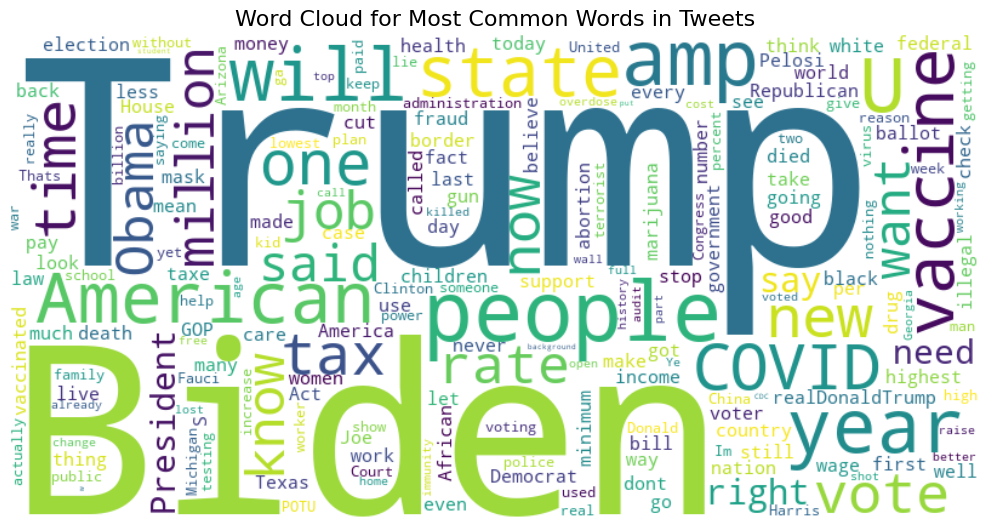

In [35]:
def generate_wordcloud(data, title, filename):
    # Combine all text - handle both DataFrame and Series
    if hasattr(data, 'tweet'):
        all_text = ' '.join(data['tweet'].astype(str))
    else:
        all_text = ' '.join(data.astype(str))

    # Create word cloud
    wordcloud = WordCloud(width=800, height=400,
                         background_color='white',
                         max_words=200,
                         collocations=False,
                         contour_width=3,
                         contour_color='steelblue').generate(all_text)

    # Display
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Usage - pass the entire DataFrame
generate_wordcloud(df, 'Word Cloud for Most Common Words in Tweets', 'TweetsWordCloud.png')


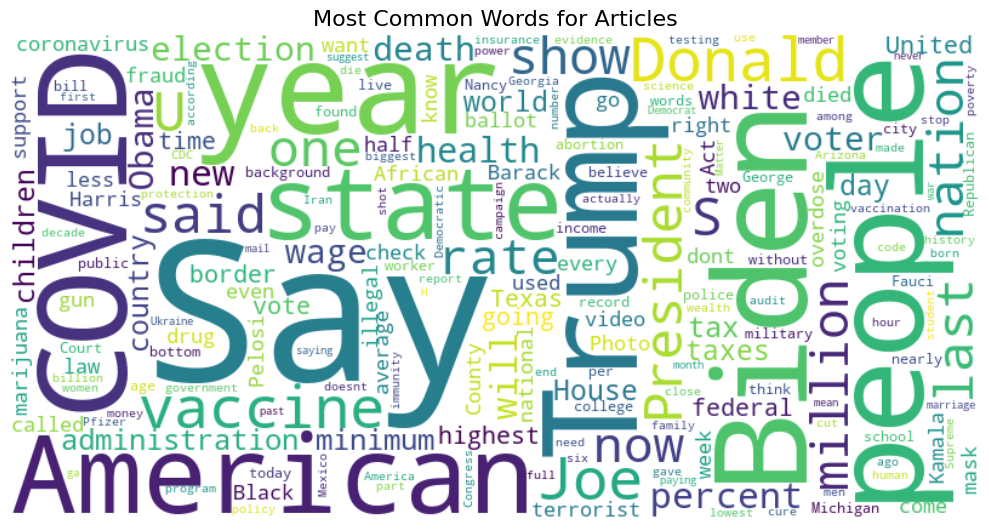

In [33]:
def generate_wordcloud(data, title, filename):
    # Combine all text - handle both DataFrame and Series
    if hasattr(data, 'statement'):
        all_text = ' '.join(data['statement'].astype(str))
    else:
        all_text = ' '.join(data.astype(str))

    # Create word cloud
    wordcloud = WordCloud(width=800, height=400,
                         background_color='white',
                         max_words=200,
                         collocations=False,
                         contour_width=3,
                         contour_color='steelblue').generate(all_text)

    # Display
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Usage - pass the entire DataFrame
generate_wordcloud(df, 'Most Common Words for Articles', 'wordcloud.png')